## Fake News Detection using LogisticRegression in Scikit-Learn

### 1. Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

### 2. Loading Dataset

In [2]:
url = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/63-Fake%20News%20Detection%20/News.csv"

In [9]:
df = pd.read_csv(url)
df.head()

,Unnamed: 0,title,text,subject,date,class
0,0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


### 3. Data Preprocessing

In [4]:
df.shape

(44919, 6)

In [5]:
df.describe()

,Unnamed: 0,class
count,44919.000000,44919.000000
mean,11253.444801,0.476792
std,6525.299017,0.499467
min,0.000000,0.000000
25%,5614.500000,0.000000
50%,11229.000000,0.000000
75%,16844.000000,1.000000
max,23501.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44919 entries, 0 to 44918
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  44919 non-null  int64 
 1   title       44919 non-null  object
 2   text        44919 non-null  object
 3   subject     44898 non-null  object
 4   date        44898 non-null  object
 5   class       44919 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 2.1+ MB


In [10]:
df = df.drop(["title", "subject","date", "Unnamed: 0"], axis = 1)

In [11]:
df.head()

,text,class
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [12]:
# Shuffling
df = df.sample(frac=1)
df.reset_index(inplace=True)
df.drop(["index"], axis=1, inplace=True)

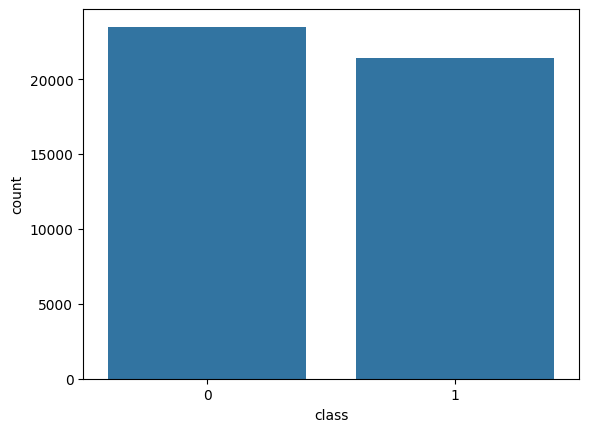

In [13]:
sns.countplot(data=df,
              x='class',
              order=df['class'].value_counts().index)
plt.show()

In [14]:
from tqdm import tqdm
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
def preprocess_text(text_data):
    preprocessed_text = []
    
    for sentence in tqdm(text_data):
        sentence = re.sub(r'[^\w\s]', '', sentence)
        preprocessed_text.append(' '.join(token.lower()
                                  for token in str(sentence).split()
                                  if token not in stopwords.words('english')))

    return preprocessed_text

In [16]:
preprocessed_review = preprocess_text(df['text'].values)
df['text'] = preprocessed_review

100%|██████████| 44919/44919 [27:23<00:00, 27.32it/s] 


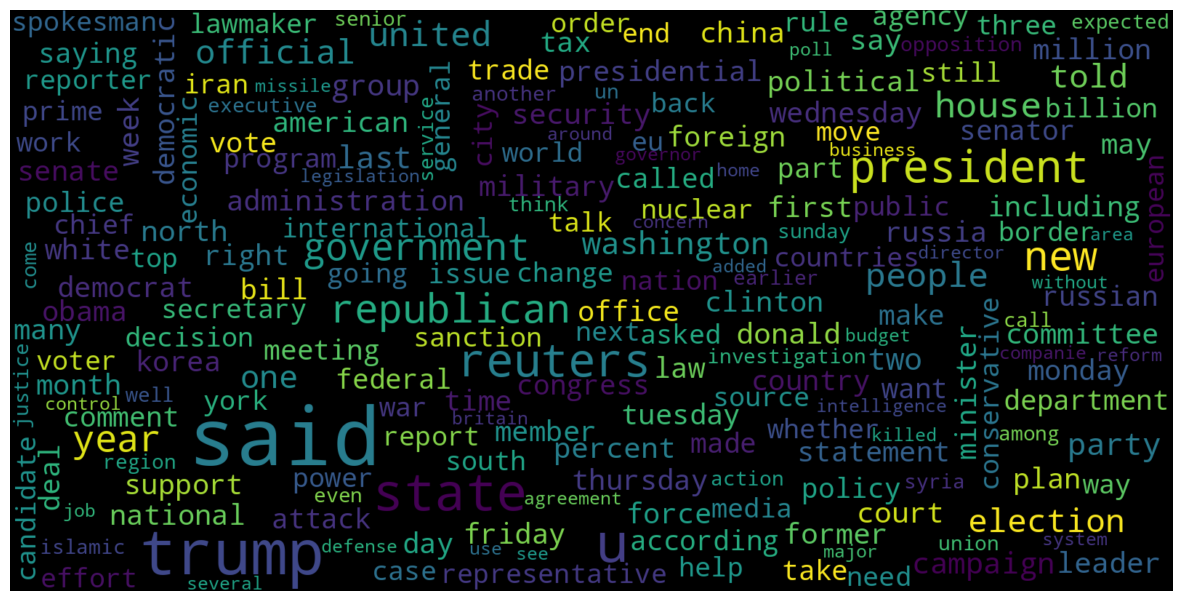

In [17]:
# Real
consolidated = ' '.join(
    word for word in df['text'][df['class'] == 1].astype(str))
wordCloud = WordCloud(width=1600,
                      height=800,
                      random_state=21,
                      max_font_size=110,
                      collocations=False)
plt.figure(figsize=(15, 10))
plt.imshow(wordCloud.generate(consolidated), interpolation='bilinear')
plt.axis('off')
plt.show()

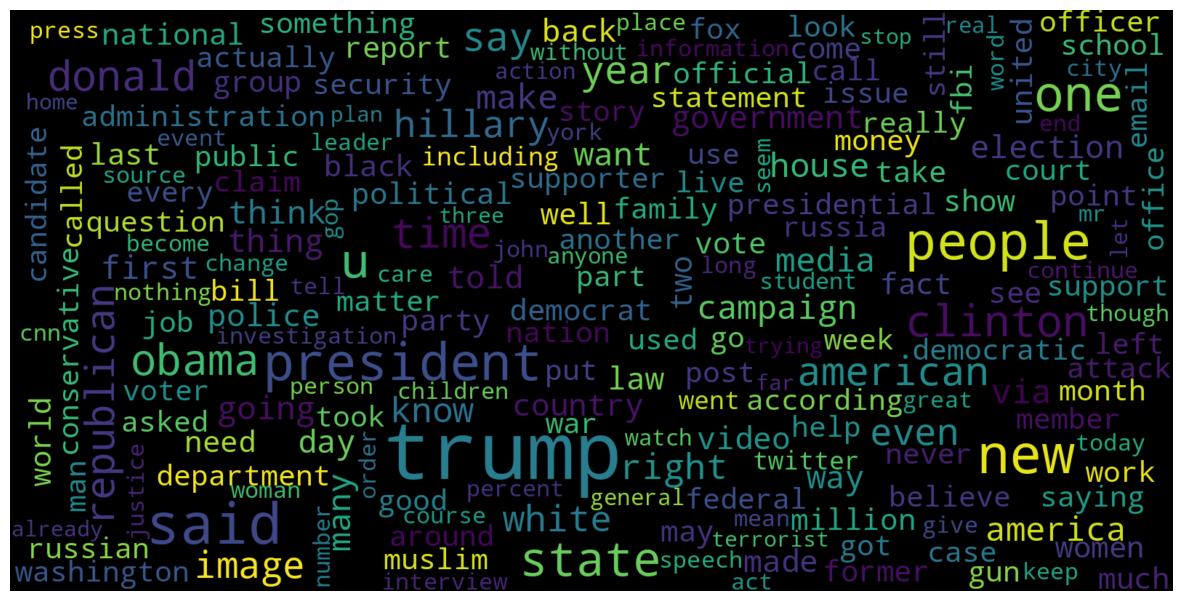

In [18]:
# Fake
consolidated = ' '.join(
    word for word in df['text'][df['class'] == 0].astype(str))
wordCloud = WordCloud(width=1600,
                      height=800,
                      random_state=21,
                      max_font_size=110,
                      collocations=False)
plt.figure(figsize=(15, 10))
plt.imshow(wordCloud.generate(consolidated), interpolation='bilinear')
plt.axis('off')
plt.show()

<Axes: title={'center': 'Bar Chart of Top Words Frequency'}, xlabel='Top Words', ylabel='Count'>

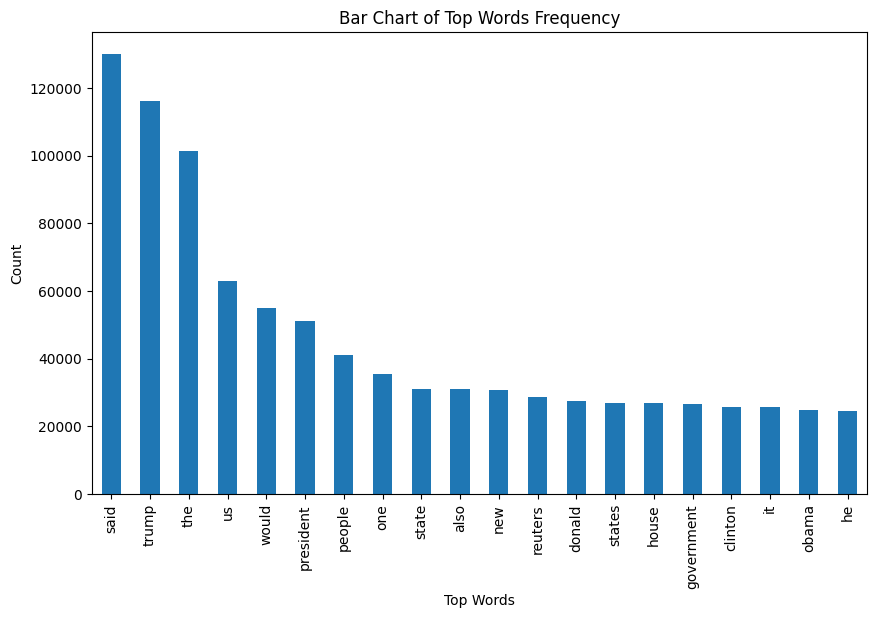

In [19]:
from sklearn.feature_extraction.text import CountVectorizer


def get_top_n_words(corpus, n=None):
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1],
                        reverse=True)
    return words_freq[:n]


common_words = get_top_n_words(df['text'], 20)
df1 = pd.DataFrame(common_words, columns=['Review', 'count'])

df1.groupby('Review').sum()['count'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10, 6),
    xlabel="Top Words",
    ylabel="Count",
    title="Bar Chart of Top Words Frequency"
)

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df['text'], 
                                                    df['class'], 
                                                    test_size=0.25)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorization = TfidfVectorizer()
x_train = vectorization.fit_transform(x_train)
x_test = vectorization.transform(x_test)

### 4. Build and Fit the Model

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_1 = LogisticRegression()
model_1.fit(x_train, y_train)

# testing the model
print(accuracy_score(y_train, model_1.predict(x_train)))
print(accuracy_score(y_test, model_1.predict(x_test)))

0.9937961946035798
0.9886019590382903


In [23]:
from sklearn.tree import DecisionTreeClassifier

model_2 = DecisionTreeClassifier()
model_2.fit(x_train, y_train)

# testing the model
print(accuracy_score(y_train, model_2.predict(x_train)))
print(accuracy_score(y_test, model_2.predict(x_test)))

0.9999703167205913
0.9958147818343722


### 5. Make Prediction

In [24]:
y_train_pred_1 = model_1.predict(x_train)
y_test_pred_1 = model_1.predict(x_test)

In [25]:
# =========================
# Predictions
# =========================
y_train_pred_2 = model_2.predict(x_train)
y_test_pred_2 = model_2.predict(x_test)

### 6. Evaluate the Model

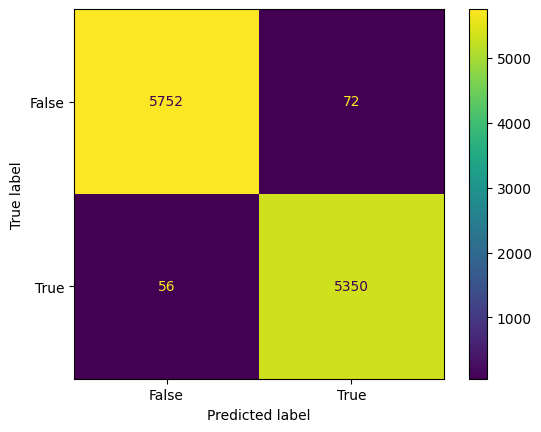

In [26]:
# Confusion matrix of Results from Decision Tree classification
from sklearn import metrics
cm_1 = metrics.confusion_matrix(y_test, model_1.predict(x_test))

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_1,
                                            display_labels=[False, True])

cm_display.plot()
plt.show()

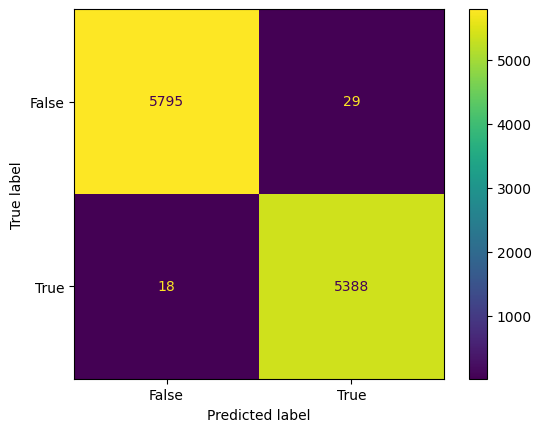

In [27]:
# Confusion matrix of Results from Decision Tree classification
from sklearn import metrics
cm_2 = metrics.confusion_matrix(y_test, model_2.predict(x_test))

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_2,
                                            display_labels=[False, True])

cm_display.plot()
plt.show()

In [29]:
# =========================
# Accuracy
# =========================
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_1))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_1))

# =========================
# Detailed Evaluation
# =========================
print("\nClassification Report (Test):")
print(metrics.classification_report(y_test, y_test_pred_1))

print("\nConfusion Matrix (Test):")
print(metrics.confusion_matrix(y_test, y_test_pred_1))

Train Accuracy: 0.9937961946035798
Test Accuracy: 0.9886019590382903

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5824
           1       0.99      0.99      0.99      5406

    accuracy                           0.99     11230
   macro avg       0.99      0.99      0.99     11230
weighted avg       0.99      0.99      0.99     11230


Confusion Matrix (Test):
[[5752   72]
 [  56 5350]]


In [30]:
# =========================
# Accuracy
# =========================
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_2))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_2))

# =========================
# Detailed Evaluation
# =========================
print("\nClassification Report (Test):")
print(metrics.classification_report(y_test, y_test_pred_2))

print("\nConfusion Matrix (Test):")
print(metrics.confusion_matrix(y_test, y_test_pred_2))

Train Accuracy: 0.9999703167205913
Test Accuracy: 0.9958147818343722

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5824
           1       0.99      1.00      1.00      5406

    accuracy                           1.00     11230
   macro avg       1.00      1.00      1.00     11230
weighted avg       1.00      1.00      1.00     11230


Confusion Matrix (Test):
[[5795   29]
 [  18 5388]]
